<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


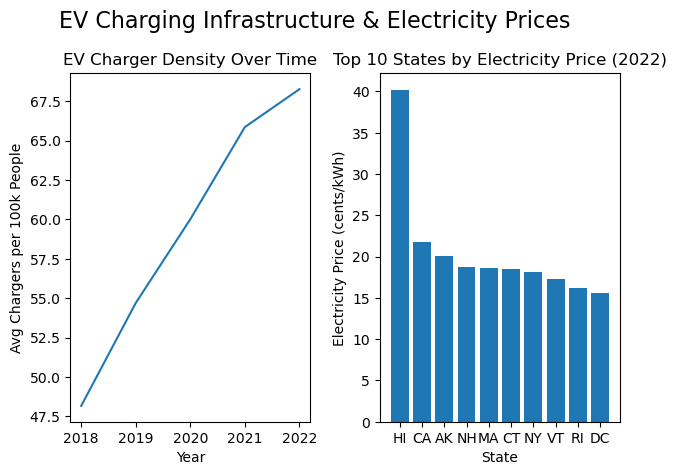

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading in my dataset
df = pd.read_csv('ev_charging_dataset.csv')

# getting the average chargers per 100k people for each year
chargers_over_time = df[['year','chargers_per_100k']].groupby('year').mean().reset_index()

# grabbing 2022 data only and finding the top 10 states with highest electricity prices
elec_by_state = df[df['year']==2022][['state','elec_price_cents_kwh']].groupby('state').mean().reset_index()
elec_by_state = elec_by_state.sort_values('elec_price_cents_kwh', ascending=False).head(10)

# creating the figure with 2 side by side plots
fig, ax = plt.subplots(nrows=1, ncols=2)

# setting up the first subplot on the left
ax1 = plt.subplot(1, 2, 1)
# plotting charger density over time as a line graph
ax1.plot(chargers_over_time['year'], chargers_over_time['chargers_per_100k'])
# labeling the x and y axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Chargers per 100k People')
# setting the title for this graph
ax1.set_title('EV Charger Density Over Time')

# setting up the second subplot on the right
ax2 = plt.subplot(1, 2, 2)
# plotting top 10 states by electricity price as a bar chart
ax2.bar(elec_by_state['state'], elec_by_state['elec_price_cents_kwh'])
# labeling the x and y axis
ax2.set_xlabel('State')
ax2.set_ylabel('Electricity Price (cents/kWh)')
# setting the title for this graph
ax2.set_title('Top 10 States by Electricity Price (2022)')

# setting the overall title for the entire figure
fig.suptitle('EV Charging Infrastructure & Electricity Prices', fontsize=16)
# cleaning up the spacing so nothing overlaps
fig.tight_layout()
plt.show()

### Graph 1: 
Charger density has been growing consistently across U.S. states from 2018 to 2022, with the steepest jump happening after 2020. This suggests that EV infrastructure investment really started accelerating in the early 2020s, likely driven by increased federal funding and rising consumer demand.

### Graph 2: 
Hawaii is a massive outlier with electricity prices almost double the next highest states, while the rest of the top 10 California, Alaska, and New Hampshire are all states known for higher energy costs. States like these are exactly where you'd expect charging operators to think twice before building out infrastructure given how much it costs to run.


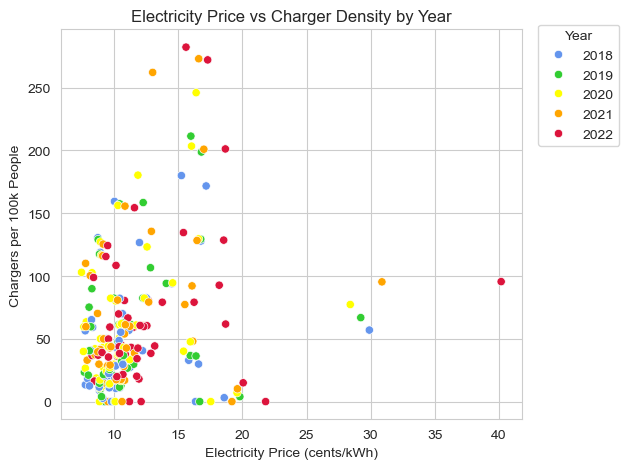

In [4]:
# graph 3 - seaborn scatter plot (not a line or bar chart)
sns.set_style('whitegrid')

# setting up a color for each year so we can tell them apart
palette3 = {2018:'cornflowerblue', 2019:'limegreen', 2020:'yellow', 2021:'orange', 2022:'crimson'}

# creating the scatter plot with electricity price on x and charger density on y
ax = sns.scatterplot(x='elec_price_cents_kwh', y='chargers_per_100k', data=df, hue='year', palette=palette3)
# moving the legend outside the plot so it doesnt cover anything
ax.legend(bbox_to_anchor=(1.02, 1.03), loc='upper left', title='Year')
# labeling the x and y axis
ax.set_xlabel('Electricity Price (cents/kWh)')
ax.set_ylabel('Chargers per 100k People')
# setting the title
ax.set_title('Electricity Price vs Charger Density by Year')

# adjusting layout so the legend doesnt get cut off
plt.tight_layout()
plt.show()

### Graph 3: 
Most of the action is clustered on the left where electricity is cheaper, and as you move right toward higher prices the dots get sparse and tend to sit lower on the y-axis. That pattern points to a pretty clear takeaway, expensive electricity and abundant charging infrastructure don't really go together.